# Quantitative analysis of finite deformation

This lab will cover methodologies to calculate deformation 
from a computational point of view.
For the ease of visualization and understanding, this lab is done in 2D. 
However, the principles of the computations are still valid even in 3D.

In [22]:
# Import the necessary libraries:
import numpy as np # linear algebra and numerical operations
import matplotlib.pyplot as plt # plotting library

To begin with, let's familiarize ourselves with some basic syntaxes of
Python numerical computations and plotting.

In [23]:
def generate_circle(center, radius):
    """
    Generates the x and y coordinates of a circle given a center and radius.
    """
    xy = [] # Python built-in list to hold the x and y coordinates of the circle

    for i in range(0, 360, 1):
        angle = np.radians(i)
        x = center[0] + radius * np.cos(angle)
        y = center[1] + radius * np.sin(angle)
        xy.append([x, y]) # grow the list by appending the new coordinates

    return np.array(xy) # convert to np.array data type for easier manipulation

In [24]:
ctr = [0.0, 0.0] # put the center of the circle at the origin
r = 1.0 # set the radius of the circle to 1.0 
xy_unit_circle = generate_circle(ctr, r) # generate the circle

Any point in space can be viewed as a vector pointing from the origin to the point itself.
Deformation in general can be viewed as a matrix-vector multiplication that
``maps'' the point from its original location to its current deformed position.
This matrix, commonly written as $\bm{F}$ is called the ``deformation gradient tensor''.
Pure shear in 2D can be written as:
$$ F =
\begin{bmatrix}
s_x & 0 \\
0   & s_y
\end{bmatrix}
$$
where $s = \frac{L_\mathrm{deformed}}{L_\mathrm{undefomed}}$ is 
the deformed-over-undeformed length ratio of a line that is parallel to x and y-axis.


As an experiment, let's plot what happens the unit circle we drew above after a pure shear deformation, 
_i.e._ the strain ellipsoid, by compressing along y-axis to half the length and stretching along x-axis to twice the length

In [36]:
sx = 2.0
sy = 1.0/sx
F = np.array([[sx, 0.0],[0.0, sy]])

Text(0.5, 1.0, 'Strain ellipsoid after pure shear with sx = 2.0, sy = 0.5')

<Figure size 640x480 with 0 Axes>

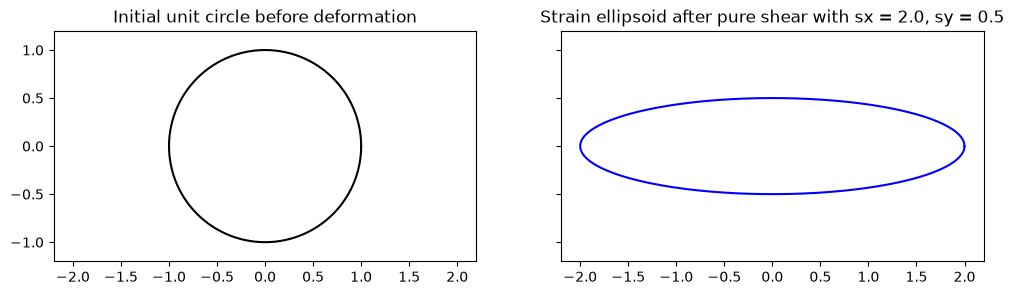

In [ ]:
plt.clf()
fig, (ax_begin, ax_end) = plt.subplots(1,2, figsize=(12, 6), sharex=True, sharey=True)

xy_pure_shear = []
for xy in xy_unit_circle:
    xy_pure_shear.append(F @ xy) # @ means matrix-vector multiplication operator
xy_pure_shear = np.array(xy_pure_shear) # convert to numpy array

# On the left, we plot the unit circle before deformation
ax_begin.plot(xy_unit_circle[:, 0], xy_unit_circle[:, 1], 'k')
ax_begin.set_aspect('equal', adjustable='box')
ax_begin.set_title("Initial unit circle before deformation")

# On the right, we plot the strain ellipsoid after deformation
ax_end.plot(xy_pure_shear[:,0], xy_pure_shear[:,1], "b-")
ax_end.set_aspect('equal', adjustable='box')
ax_end.set_ylim([-1.2, 1.2])
ax_end.set_title(f"Strain ellipsoid after pure shear with sx = {sx}, sy = {sy}")

The blue ellipsoid is in fact the stain ellipsoid related to this deformation.
What happens to the lengths of the lines before and after the deformation?
Recall that for a vector $\boldsymbol{x} = (x_1, x_2)$, its length is the Euclidean norm: $\|\boldsymbol{x}\| = \sqrt{x_1^2 +x_2^2}$.
Let's populate a set of lines inside the unit circle and test how the deformation changes their lengths.

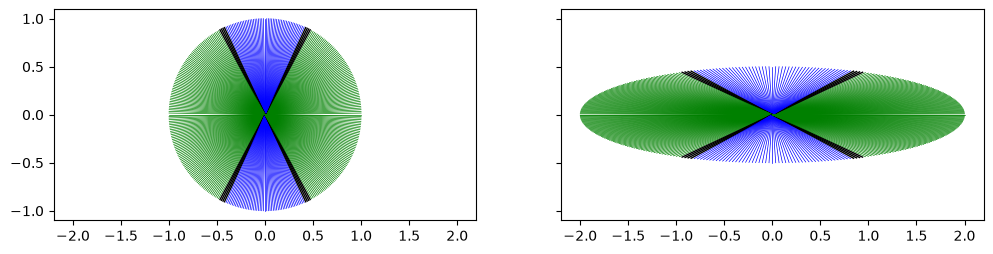

In [27]:
def stretching_or_shortening(xy_initial, xy_final, tol = 5e-2):
    """
    Computes the stretching or shortening of a line segment 
    defined by two points before and after deformation.
    """
    # Compute the initial length of the line segment
    initial_length = np.linalg.norm(xy_initial, axis=1)

    # Compute the final length of the line segment
    final_length = np.linalg.norm(xy_final, axis=1)

    # Compute the stretching or shortening factor
    stretch_factor = final_length / initial_length - 1.0
    stretch_factor[np.abs(stretch_factor) < tol] = 0.0 # set values below tolerance to zero

    # return sign function, positive for stretching, negative for shortening, zero for no change
    return np.sign(stretch_factor)


fig, (axi, axf) = plt.subplots(1,2, figsize=(12, 6), sharex=True, sharey=True)
stretch_factors = stretching_or_shortening(xy_unit_circle, xy_pure_shear)

for sf, xy_initial, xy_final in zip(stretch_factors, xy_unit_circle, xy_pure_shear):
    if sf > 0: # stretched lines are colored in green
        axi.plot([0,xy_initial[0]], [0,xy_initial[1]], 'g', linewidth=0.5)
        axf.plot([0,xy_final[0]], [0,xy_final[1]], 'g', linewidth=0.5)
    elif sf < 0: # shortened lines are colored in blue
        axi.plot([0,xy_initial[0]], [0,xy_initial[1]], 'b', linewidth=0.5)
        axf.plot([0,xy_final[0]], [0,xy_final[1]], 'b', linewidth=0.5)
    else: # lines with negligible length change are colored black
        axi.plot([0,xy_initial[0]], [0,xy_initial[1]], 'k', linewidth=1)
        axf.plot([0,xy_final[0]], [0,xy_final[1]],'k', linewidth=1)

axi.set_aspect('equal', adjustable='box')
axf.set_aspect('equal', adjustable='box')

You can also quantify the rotation angle and direction of rotation (whether the rotation is clockwise or counterclockwise) 

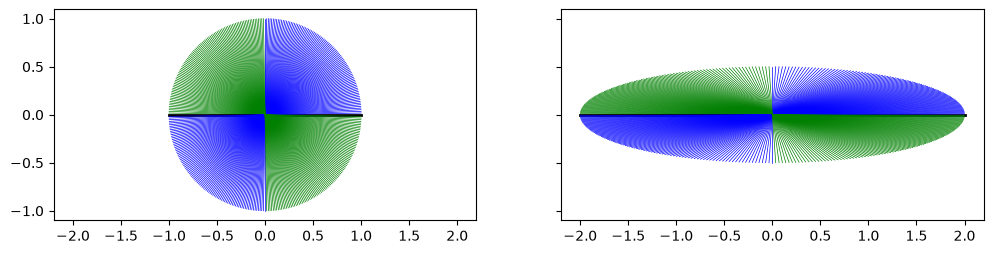

In [28]:
def rotation_direction(xy_initial, xy_final, tol = 5.0e-2):
    """
    Computes the rotation direction of a line segment defined by two points before and after deformation.
    """
    # Compute the initial angle of the line segment
    initial_angle = np.arctan2(xy_initial[:,1], xy_initial[:,0]) % (2*np.pi)
    final_angle = np.arctan2(xy_final[:,1], xy_final[:,0]) % (2*np.pi)

    # Compute the rotation direction
    rotation_angle = final_angle - initial_angle
    rotation_angle = np.sign(rotation_angle)
    rotation_angle[np.abs(rotation_angle) < tol] = 0.0 # set values below tolerance to zero

    return np.sign(rotation_angle)


fig, (axi, axf) = plt.subplots(1,2, figsize=(12, 6), sharex=True, sharey=True)
stretch_factors = rotation_direction(xy_unit_circle, xy_pure_shear)

for sf, xy_initial, xy_final in zip(stretch_factors, xy_unit_circle, xy_pure_shear):
    if sf > 0:
        axi.plot([0,xy_initial[0]], [0,xy_initial[1]], 'g', linewidth=0.5)
        axf.plot([0,xy_final[0]], [0,xy_final[1]], 'g', linewidth=0.5)
    elif sf < 0:
        axi.plot([0,xy_initial[0]], [0,xy_initial[1]], 'b', linewidth=0.5)
        axf.plot([0,xy_final[0]], [0,xy_final[1]], 'b', linewidth=0.5)
    else:
        axi.plot([0,xy_initial[0]], [0,xy_initial[1]], 'k', linewidth=2)
        axf.plot([0,xy_final[0]], [0,xy_final[1]],'k', linewidth=2)

axi.set_aspect('equal', adjustable='box')
axf.set_aspect('equal', adjustable='box')